In [1]:
from __future__ import annotations
# ═════════════ IMPORTS & CONFIG ═════════════════════════════════════════
import logging, warnings, joblib
from pathlib import Path
from typing   import Dict, List, Tuple
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold, chi2, f_classif
from sklearn.preprocessing      import OneHotEncoder, MinMaxScaler
from sklearn.metrics            import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from keras.layers import LSTM, GRU, Dense, Dropout, Bidirectional
from keras.regularizers import l2

from statsmodels.tsa.seasonal import seasonal_decompose

# warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
tf.config.run_functions_eagerly(False)
tf.keras.utils.set_random_seed(42)

# Optionally limit CPU threads (or set to all with os.cpu_count())
tf.config.threading.set_intra_op_parallelism_threads(os.cpu_count())
tf.config.threading.set_inter_op_parallelism_threads(os.cpu_count())

# ═════════════ RUTAS & CONSTANTES ═══════════════════════════════════════
BASE_PATH      = Path("../")
DATA_BASE_PATH = BASE_PATH / "data/pipeline"
PREPARED_BASE_PATH   = DATA_BASE_PATH / "prepared"
RESULTS_PATH   = BASE_PATH / "resultados/iteracion_6"

DATA_FROM = {
    "train": PREPARED_BASE_PATH / "train.csv",
    "test": PREPARED_BASE_PATH / "test.csv",
    "submission": PREPARED_BASE_PATH / "sample_submission.csv"
}

LOW_VAR, HIGH_CORR = 0.01, 0.95

# ═════════════ ARCHIVOS ═══════════════════════════════════════
import sys
sys.path.append('../pipeline')
from preprocess import feature_engineering



2025-06-08 21:58:40.106341: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749441520.169502 2689402 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749441520.188735 2689402 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749441520.335999 2689402 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749441520.336018 2689402 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749441520.336019 2689402 computation_placer.cc:177] computation placer alr

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_visible_devices(gpus[0], 'GPU')

In [3]:
def get_df(file_name: str, teq_type: str = "teq") -> pd.DataFrame:
    """
    Carga los DataFrames de entrenamiento y prueba desde las rutas especificadas.
    """
    train_df = pd.read_csv(PREPARED_BASE_PATH / f"{file_name}_{teq_type}_train.csv")
    test_df = pd.read_csv(PREPARED_BASE_PATH / f"{file_name}_{teq_type}_test.csv")
    
    return pd.concat([train_df, test_df])
    
    

# LSTM Auxiliary function

In [4]:
## Auxiliares LSTM
def sliding_window_lstm(Xdata_df: pd.DataFrame, ydata_df: pd.Series, window_size: int, optional_cols: List[str] = None):
    X, y = [], []
    dict_col_array = {}

    #Create a sliding window
    for i in range(window_size, len(ydata_df)):
        X.append(ydata_df.iloc[i-window_size:i].values) # Agregamos ydata para entrenar y predecir un paso en el futuro
        y.append(ydata_df.iloc[i])

    if optional_cols is not None and len(optional_cols) > 0:
        for col in optional_cols:
            aux_arr = []
            for i in range(window_size, len(Xdata_df)):
                aux_arr.append(Xdata_df.iloc[i-window_size:i][col].values)
                
            aux_arr = np.array(aux_arr)
            dict_col_array[col] = aux_arr
            

    X, y = np.array(X), np.array(y)

    if optional_cols is not None and len(optional_cols) > 0:
        X = X.reshape(X.shape[0], X.shape[1], 1)

        for _, val in dict_col_array.items():
            X = np.insert(X, -1, val, axis=2)
    else:
        X = np.reshape(X, (X.shape[0], X.shape[1], 1 ))

    return X, y

def get_seasonal_decompose_data(data_df: pd.DataFrame, target_col: str = "Valor"):
    res_decompose = seasonal_decompose(data_df[target_col], model='additive', extrapolate_trend='freq')

    data_df["seasonal"] = res_decompose.seasonal
    data_df["trend"] = res_decompose.trend
    data_df["resid"] = res_decompose.resid

    return data_df

def plot_decompose_data(data_decomposed_df: pd.DataFrame, observed_col: str = "Valor", v_line: float = 0):
    # res_decompose = seasonal_decompose(full_sc["Valor"], model='additive', extrapolate_trend='freq')

    fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(18, 12), sharex=True)
    data_decomposed_df[observed_col].plot(ax=axs[0])
    axs[0].set_title('Serie original', fontsize=12)
    axs[0].grid()

    data_decomposed_df["trend"].plot(ax=axs[1])
    axs[1].set_title('Tendencia', fontsize=12)
    axs[1].grid()

    data_decomposed_df["seasonal"].plot(ax=axs[2])
    axs[2].set_title('Estacionalidad', fontsize=12)
    axs[2].grid()

    data_decomposed_df["resid"].plot(ax=axs[3])
    axs[3].set_title('Residuos', fontsize=12)
    axs[3].grid()

    if v_line > 0:
        for i in range(len(axs)):
            xmin, xmax = axs[i].get_xlim()
            x_position = xmin + (xmax - xmin) * 0.8
            axs[i].axvline(x=x_position, color='r', linestyle='--')


    fig.suptitle('Descomposición de la serie original vs serie diferenciada', fontsize=14)
    fig.tight_layout()

def lstm_model(input_shape):
    # Build the Model
    model = keras.models.Sequential()

    model.add(keras.layers.LSTM(64, return_sequences=True, input_shape=input_shape))
    model.add(keras.layers.LSTM(64, return_sequences=False))
    model.add(keras.layers.Dense(128, activation="relu"))
    model.add(keras.layers.Dense(1))

    # model.summary()
    model.compile(optimizer="adam",
                loss="mae",
                metrics=[keras.metrics.RootMeanSquaredError()])
    
    return model

def Xy_split(train_df: pd.DataFrame, target_col: str = "Valor"):
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]

    return X_train, y_train



In [5]:
def walk_forward_validation(data_df: pd.DataFrame, target_col:str = "Valor", training_window: int = 36, test_window: int = 1):
    """
    Walk-forward validation for time series forecasting.
    """
    actuals = []
    predictions = []
    prediction_seas_trends = []
    prediction_resids = []
    metrics_trend_season = []
    sliding_window_size = 24

    for i in range(0,
                   len(data_df) - training_window - test_window,
                    test_window):
        
        # Split into train-test sets
        train_data = data_df[i:i + training_window]
        test_data = data_df[i + training_window : i + training_window + test_window]

        train_data, ohe, minmax_sc = feature_engineering(train_data, "", target_col, LOW_VAR, HIGH_CORR, ignore_lags=True)
        test_data, _, _ = feature_engineering(test_data, "", target_col, LOW_VAR, HIGH_CORR, ohe, minmax_sc, train_data.columns.to_list(), ignore_lags=True)

        train_data = train_data.set_index('Fecha')
        test_data = test_data.set_index('Fecha')

        # Decompose
        train_dec_df = get_seasonal_decompose_data(train_data, target_col)
        train_dec_df["sea_trend"] = train_dec_df["seasonal"] + train_dec_df["trend"]
        
        # ════════════════════════════════════════════════════ Prediccion con Trend y Seasonal ═══════════════════════════════════════
        # Divide into X and y
        X_train, y_train,  = Xy_split(train_dec_df, "sea_trend")
        _, y_test = Xy_split(test_data, target_col)    

        # Create sliding window
        X_train_sw, y_train_sw = sliding_window_lstm(X_train, y_train, window_size=sliding_window_size, optional_cols=["seasonal", "trend"])

        # Create the model and fit for the data using seasonal and trend data
        model = lstm_model((X_train_sw.shape[1], X_train_sw.shape[2]))
        model.fit(X_train_sw, y_train_sw, epochs=50, batch_size=32, verbose=0)

        # Make a Prediction
        ltsm_predictions_seas_trend = model.predict(X_train_sw[-1:].copy())        
        unscaled_prediction_seatrend = minmax_sc.inverse_transform(np.pad(ltsm_predictions_seas_trend, ((0, 0), (0, len(minmax_sc.feature_names_in_) - 1)), mode='constant'))
        # ════════════════════════════════════════════════════ Prediccion del residuo (ruido) ═══════════════════════════════════════
        X_train, y_train,  = Xy_split(train_dec_df, "resid")

        # Create sliding window
        X_train_sw, y_train_sw = sliding_window_lstm(X_train, y_train, window_size=sliding_window_size, optional_cols=['Mes_Aug', 'Mes_Dec', 'Mes_Feb', 'Mes_Jan', 'Mes_Jul', 'Mes_Jun', 'Mes_Mar', 'Mes_May', 'Mes_Nov', 'Mes_Oct', 'Mes_Sep', "seasonal", "trend"])

        # Create the model and fit for the data using seasonal and trend data
        model_resid = lstm_model((X_train_sw.shape[1], X_train_sw.shape[2]))
        model_resid.fit(X_train_sw, y_train_sw, epochs=20, batch_size=32, verbose=0)

        # Make a Prediction
        ltsm_predictions_resid = model_resid.predict(X_train_sw[-1:].copy())
        unscaled_prediction_resid = minmax_sc.inverse_transform(np.pad(ltsm_predictions_resid, ((0, 0), (0, len(minmax_sc.feature_names_in_) - 1)), mode='constant'))

        yhat = ltsm_predictions_seas_trend + ltsm_predictions_resid
        unscaled_prediction = minmax_sc.inverse_transform(np.pad(yhat, ((0, 0), (0, len(minmax_sc.feature_names_in_)-1)), mode='constant'))
        
        prediction_seas_trend = unscaled_prediction_seatrend[0, 0:1]
        prediction_resid = unscaled_prediction_resid[0, 0:1]
        prediction = unscaled_prediction[0, 0:1]

        predictions.extend(prediction)
        prediction_seas_trends.extend(prediction_seas_trend)
        prediction_resids.extend(prediction_resid)
        actuals.extend(y_test.values)

    # return predictions, actuals, metrics_trend_season, metrics_resid
    return {
        "predictions": {
            "seas_trend": prediction_seas_trends,
            "resid": prediction_resids,
            "total": predictions
        },
        "actuals": actuals,
        "metrics_trend_season": metrics_trend_season
    }

In [6]:
full_sc = get_df("exportaciones_pais", "teq")
full_sc

,Valor,Year,Mes
0,5829070.98,1997,1
1,5532315.75,1997,2
2,5265032.53,1997,3
3,5745381.50,1997,4
4,5561477.54,1997,5
...,...,...,...
63,4780939.88,2024,11
64,6789662.05,2024,12
65,6444358.59,2025,1
66,4990450.92,2025,2


In [7]:
resultados = walk_forward_validation(full_sc, target_col="Valor", training_window=36, test_window=1)

INFO | ··· FE:  ···
INFO | ··· FE:  ···


Creating new OneHotEncoder
Creating new MinMaxScaler


I0000 00:00:1749441523.475805 2689402 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5564 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:0b:00.0, compute capability: 8.6
I0000 00:00:1749441526.977015 2689481 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


INFO | ··· FE:  ···
INFO | ··· FE:  ···


...

Creating new OneHotEncoder
Creating new MinMaxScaler
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


INFO | ··· FE:  ···
INFO | ··· FE:  ···


Creating new OneHotEncoder
Creating new MinMaxScaler
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


INFO | ··· FE:  ···
INFO | ··· FE:  ···


Creating new OneHotEncoder
Creating new MinMaxScaler
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


In [ ]:
len(resultados["predictions"]["seas_trend"])
# len(full_sc.index) - 

302

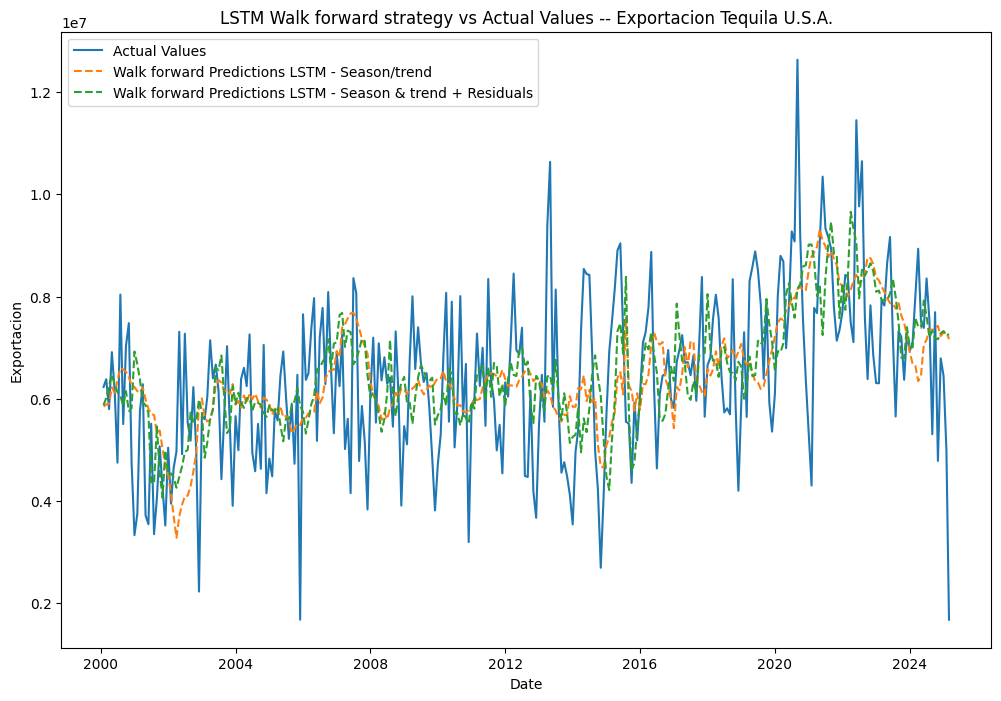

In [9]:
wf_df = full_sc[37:].copy()
wf_df["Fecha"] = pd.to_datetime(
        wf_df["Year"].astype(str) + "-" + wf_df["Mes"].astype(str).str.zfill(2)
    )
wf_df = wf_df.set_index('Fecha')

# wf_df["Walk_forward_resid"] = resultados["predictions"]["resid"]
wf_df["Walk_forward_seas_trend"] = resultados["predictions"]["seas_trend"]
wf_df["Walk_forward_total"] = resultados["predictions"]["total"]
# wf_df["Walk_forward_seas_trend_resid_mean"] = (wf_df["Walk_forward_seas_trend"] + wf_df["Walk_forward_resid"]) / 2

plt.figure(figsize=(12,8))
plt.plot(wf_df.index, wf_df['Valor'], label="Actual Values")
plt.plot(wf_df.index, wf_df["Walk_forward_seas_trend"], label="Walk forward Predictions LSTM - Season/trend", linestyle='--')
# plt.plot(wf_df.index, wf_df["Walk_forward_resid"], label="Walk forward Predictions LSTM - Residuals", linestyle='--')
plt.plot(wf_df.index, wf_df["Walk_forward_total"], label="Walk forward Predictions LSTM - Season & trend + Residuals", linestyle='--')
# plt.plot(wf_df.index, wf_df["Walk_forward_seas_trend_resid_mean"], label="Walk forward Predictions LSTM - (Season & trend + Residuals) / 2", linestyle='--')

plt.title("LSTM Walk forward strategy vs Actual Values -- Exportacion Tequila U.S.A.")
plt.xlabel("Date")
plt.ylabel("Exportacion")
plt.legend()
plt.show()

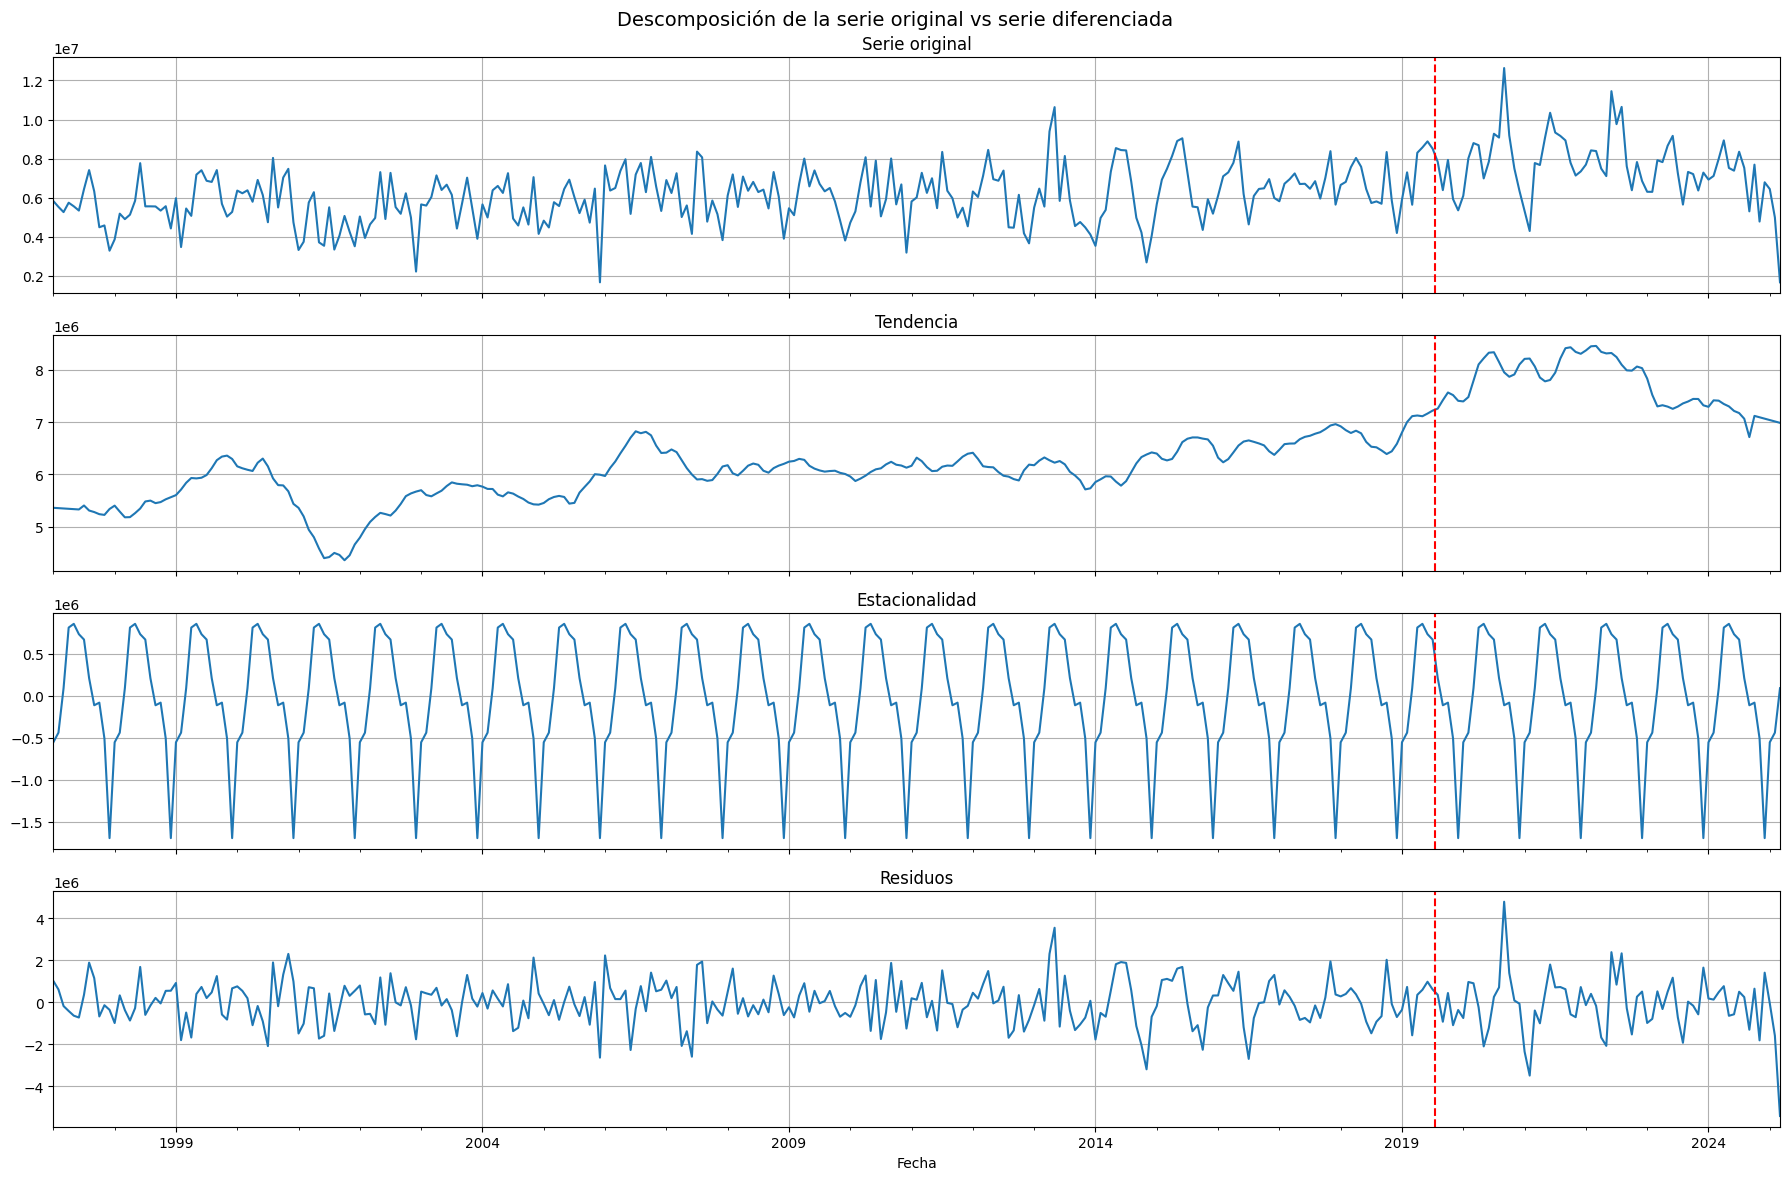

In [10]:
full_sc["Fecha"] = pd.to_datetime(
        full_sc["Year"].astype(str) + "-" + full_sc["Mes"].astype(str).str.zfill(2)
    )
full_sc = full_sc.set_index('Fecha')

plot_decompose_data(get_seasonal_decompose_data(full_sc), v_line=0.8)

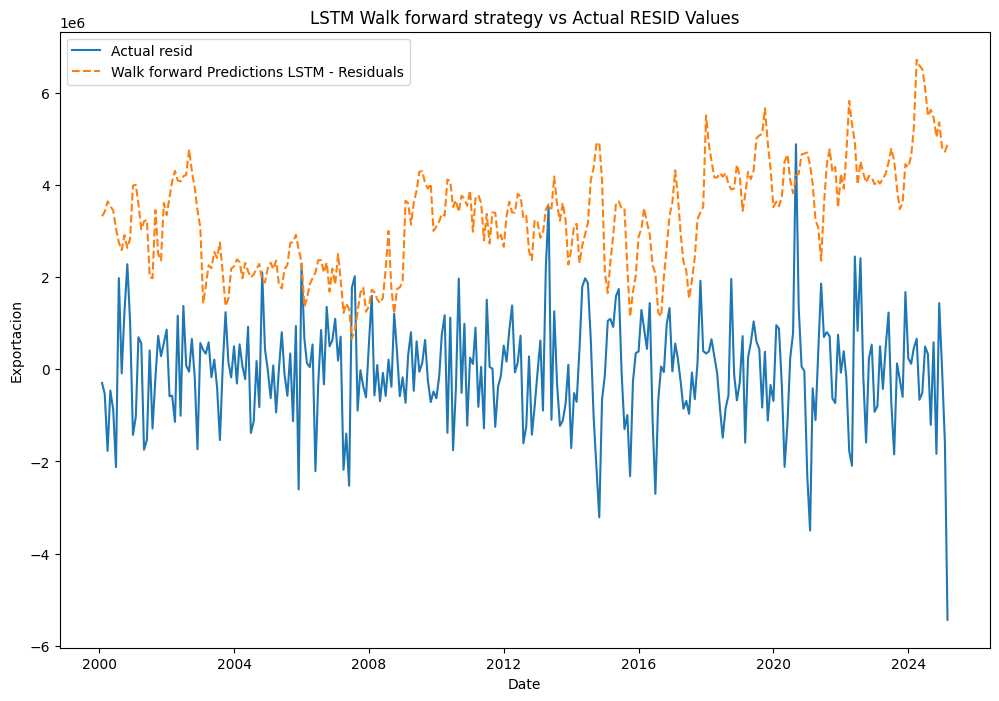

In [11]:
# full_sc = get_seasonal_decompose_data(full_sc, "Valor")
wf_df = get_seasonal_decompose_data(full_sc[37:].copy(), "Valor")


wf_df["Walk_forward_resid"] = resultados["predictions"]["resid"]

plt.figure(figsize=(12,8))
plt.plot(wf_df.index, wf_df['resid'], label="Actual resid")

plt.plot(wf_df.index, wf_df["Walk_forward_resid"], label="Walk forward Predictions LSTM - Residuals", linestyle='--')
# plt.plot(wf_df.index, wf_df["Walk_forward_seas_trend_resid_mean"], label="Walk forward Predictions LSTM - (Season & trend + Residuals) / 2", linestyle='--')

plt.title("LSTM Walk forward strategy vs Actual RESID Values")
plt.xlabel("Date")
plt.ylabel("Exportacion")
plt.legend()
plt.show()

In [12]:
full_teq100_sc = get_df("exportaciones_pais", "teq100")
full_teq100_sc

resultados_100 = walk_forward_validation(data_df=full_teq100_sc, target_col="Valor", training_window=36, test_window=1)

INFO | ··· FE:  ···
INFO | ··· FE:  ···


Creating new OneHotEncoder
Creating new MinMaxScaler
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


INFO | ··· FE:  ···
INFO | ··· FE:  ···


Creating new OneHotEncoder
Creating new MinMaxScaler
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


INFO | ··· FE:  ···
INFO | ··· FE:  ···


...

Creating new OneHotEncoder
Creating new MinMaxScaler
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step


INFO | ··· FE:  ···


Creating new OneHotEncoder


INFO | ··· FE:  ···


Creating new MinMaxScaler


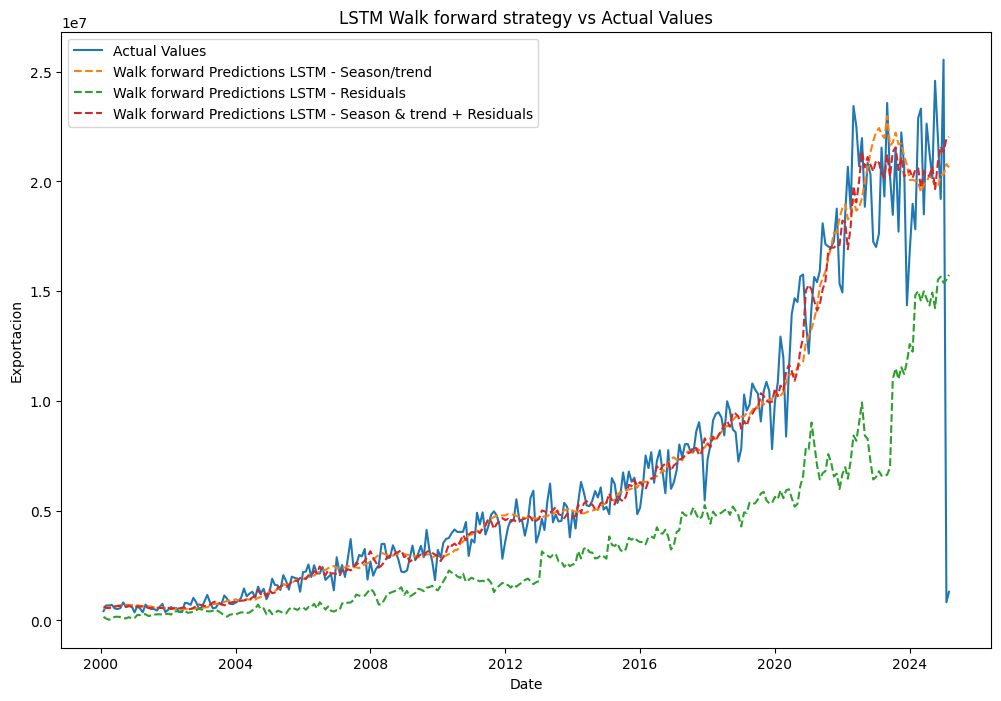

In [ ]:
full_teq100_sc
resultados_100

wf_df = full_teq100_sc[37:].copy()
wf_df["Fecha"] = pd.to_datetime(
        wf_df["Year"].astype(str) + "-" + wf_df["Mes"].astype(str).str.zfill(2)
    )
wf_df = wf_df.set_index('Fecha')

wf_df["Walk_forward_resid"] = resultados_100["predictions"]["resid"]
wf_df["Walk_forward_seas_trend"] = resultados_100["predictions"]["seas_trend"]
wf_df["Walk_forward_total"] = resultados_100["predictions"]["total"]
# wf_df["Walk_forward_seas_trend_resid_mean"] = (wf_df["Walk_forward_seas_trend"] + wf_df["Walk_forward_resid"]) / 2

plt.figure(figsize=(12,8))
plt.plot(wf_df.index, wf_df['Valor'], label="Actual Values")
plt.plot(wf_df.index, wf_df["Walk_forward_seas_trend"], label="Walk forward Predictions LSTM - Season/trend", linestyle='--')
plt.plot(wf_df.index, wf_df["Walk_forward_resid"], label="Walk forward Predictions LSTM - Residuals", linestyle='--')
plt.plot(wf_df.index, wf_df["Walk_forward_total"], label="Walk forward Predictions LSTM - Season & trend + Residuals", linestyle='--')
# plt.plot(wf_df.index, wf_df["Walk_forward_seas_trend_resid_mean"], label="Walk forward Predictions LSTM - (Season & trend + Residuals) / 2", linestyle='--')

plt.title("LSTM Walk forward strategy vs Actual Values")
plt.xlabel("Date")
plt.ylabel("Exportacion")
plt.legend()
plt.show()

In [12]:
wf_df = wf_df.drop(columns=['Year','Mes'], errors='ignore')
wf_df.to_csv(f'exportaciones_pais_teq100_predictions.csv', index=True)
